# **Depth Estimation with Unet++**

contact: shayanrokhva1999@gmail.com

## **Imports**

In [1]:
!pip install -Uq segmentation-models-pytorch

In [2]:
# ===============================
# Core Libraries
# ===============================

import numpy as np              # Numerical operations (arrays, math, matrix ops)
import pandas as pd             # Data handling (CSV files, tabular data)

# ===============================
# PyTorch & Deep Learning
# ===============================

import torch                    # Main PyTorch library
import torch.nn as nn           # Neural network modules (layers, loss functions)

# Mixed Precision Training (faster + less memory usage on GPU)
from torch.cuda.amp import GradScaler, autocast  

# ===============================
# Visualization & Utilities
# ===============================

import matplotlib.pyplot as plt # Plotting graphs and images
from tqdm.auto import tqdm      # Progress bars for training loops
from pathlib import Path        # Handling filesystem paths in a clean way
import gc                       # Manual garbage collection (free memory)

# ===============================
# Image Processing
# ===============================

import cv2 as cv                # OpenCV for image loading/processing
from PIL import Image           # Alternative image loading utility

# ===============================
# Model Architecture
# ===============================

import segmentation_models_pytorch as smp  # Prebuilt segmentation models (e.g., U-Net++)

# ===============================
# Data Splitting
# ===============================

from sklearn.model_selection import train_test_split  # Train/validation split

# ===============================
# Data Augmentation
# ===============================

import albumentations as A
from albumentations.pytorch import ToTensorV2  # Convert augmented images to PyTorch tensors

# ===============================
# Evaluation Metrics
# ===============================

from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM  # Image similarity metric
from torchmetrics.regression import MeanSquaredError as MSE              # Regression error metric
from torchmetrics.collections import MetricCollection                    # Group multiple metrics together

# ===============================
# Image Normalization
# ===============================

from torchvision.transforms import Normalize  # Normalize image tensors (mean/std scaling)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: l

## **Train/Val/Test & Visualization**
#### Brighter colors means more depth


In [3]:
# Path to the CSV file that contains training image and depth map references
train_csv = Path('/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_train.csv')

# Directory containing the RGB training images
train_ims_path = Path('/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_train')

# Base directory of the NYU Depth v2 dataset (used for accessing other resources if needed)
base_path = Path('/kaggle/input/nyu-depth-v2/nyu_data')

In [4]:
# Load the CSV file containing image paths and corresponding depth map paths
# header=None because the CSV does not include column names
df = pd.read_csv(train_csv, header=None)

# Convert relative image paths to absolute paths by joining them with the dataset base path
df[0] = df[0].map(lambda x: base_path / x)

# Do the same for depth map paths
df[1] = df[1].map(lambda x: base_path / x)

# Display the first few rows to verify that paths are loaded correctly
df.head()

,0,1
0,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...
1,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...
2,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...
3,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...
4,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...,/kaggle/input/nyu-depth-v2/nyu_data/data/nyu2_...


In [5]:
# Split the dataset into training and temporary validation sets (10% for validation/test pool)
train_df, val_df = train_test_split(df, test_size=0.1, shuffle=True)

# Further split the temporary set into validation and test sets
val_df, test_df = train_test_split(val_df, test_size=0.1, shuffle=True)

# Reset indices to keep DataFrame indexing clean after splitting
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

# Print the number of samples in each split
len(train_df), len(val_df), len(test_df)

(45619, 4562, 507)

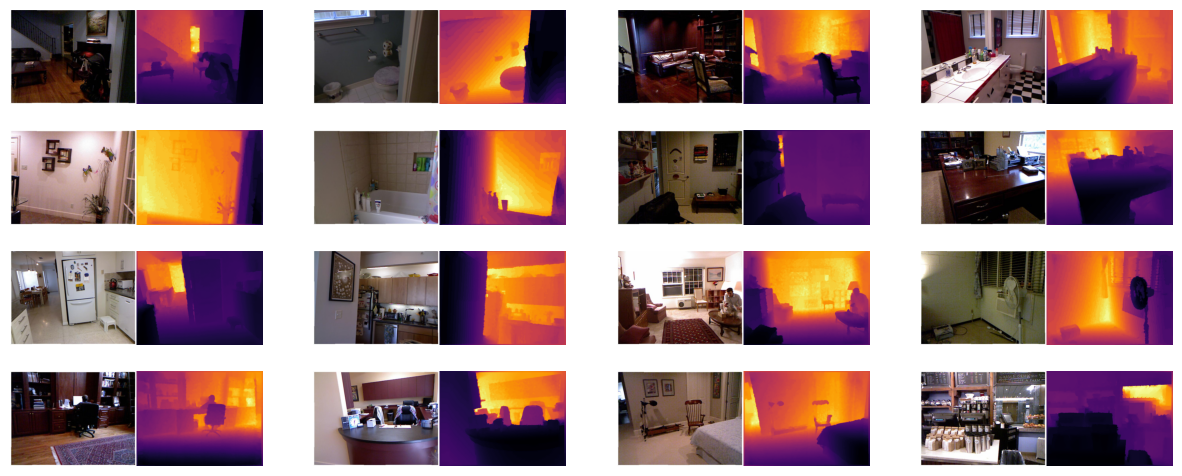

In [6]:
# -----------------------------------------
# Convert a depth map to a colored visualization
# -----------------------------------------
def colored_depthmap(depth, d_min=None, d_max=None, cmap=plt.cm.inferno):
    
    # If min/max depth are not provided, compute them from the depth map
    if d_min is None:
        d_min = np.min(depth)
    if d_max is None:
        d_max = np.max(depth)

    # Normalize depth values to range [0, 1]
    depth_relative = (depth - d_min) / (d_max - d_min)

    # Apply colormap and keep only RGB channels (ignore alpha)
    return 255 * cmap(depth_relative)[:, :, :3]  # Output shape: H, W, C


# -----------------------------------------
# Merge RGB image and its depth map for visualization
# -----------------------------------------
def merge_into_row(input, depth_target):

    # Convert PIL images to numpy arrays
    input = np.array(input)
    depth_target = np.squeeze(np.array(depth_target))

    # Compute depth range for consistent coloring
    d_min = np.min(depth_target)
    d_max = np.max(depth_target)

    # Convert depth map to colored representation
    depth_target_col = colored_depthmap(depth_target, d_min, d_max)

    # Concatenate RGB image and colored depth map horizontally
    img_merge = np.hstack([input, depth_target_col])
    
    return img_merge


# -----------------------------------------
# Visualize random samples from the dataset
# -----------------------------------------
plt.figure(figsize=(15, 6))

# Select 16 random samples
for i, idx in enumerate(np.random.randint(0, len(df), (16,))):

    ax = plt.subplot(4, 4, i + 1)

    # Load RGB image
    image = Image.open(df.iloc[idx, 0]).convert('RGB')

    # Load corresponding depth map (grayscale)
    mask = Image.open(df.iloc[idx, 1]).convert('L')

    # Create a merged visualization (image + depth map)
    image_viz = merge_into_row(image, mask)

    # Display the result
    plt.imshow(image_viz.astype("uint8"))
    plt.axis("off")


## **Dataset and Transformtations(Augmentations)**
<div style="width:100%;height:0;border-bottom: 3px solid #F7F437;margin-bottom: 1rem;"></div>


In [7]:
# -----------------------------------------
# Data Augmentation for Training Samples
# -----------------------------------------

sample_tfms = [
    A.HorizontalFlip(),                 # Random horizontal flip for better generalization
    
    A.GaussNoise(p=0.2),                # Add random Gaussian noise with 20% probability
    
    # Randomly apply one type of blur
    A.OneOf([
        A.MotionBlur(p=.3),             # Simulate motion blur
        A.MedianBlur(blur_limit=3, p=0.3),  # Median blur to reduce noise
        A.Blur(blur_limit=3, p=0.5),    # Standard blur
    ], p=0.3),

    A.RGBShift(),                       # Random shift in RGB color channels
    A.RandomBrightnessContrast(),       # Random brightness and contrast adjustment

    A.RandomResizedCrop(384, 384),      # Random crop and resize for spatial variability
    A.ColorJitter(),                    # Random color jittering

    # Random spatial transformation: shift, scale, and rotation
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.3,
        rotate_limit=45,
        p=0.5
    ),

    A.HueSaturationValue(p=0.3),        # Random change in hue, saturation, and value
]


# -----------------------------------------
# Training Transform Pipeline
# -----------------------------------------

train_tfms = A.Compose([
    *sample_tfms,                       # Apply all augmentation transforms
    A.Resize(224, 224),                 # Resize images to model input size
    A.Normalize(always_apply=True),     # Normalize pixel values
    ToTensorV2()                        # Convert images to PyTorch tensors
])


# -----------------------------------------
# Validation / Test Transform Pipeline
# -----------------------------------------

valid_tfms = A.Compose([
    A.Resize(224, 224),                 # Only resize (no augmentation)
    A.Normalize(always_apply=True),     # Normalize using same settings as training
    ToTensorV2()                        # Convert to PyTorch tensor
])

In [8]:
# -----------------------------------------
# Custom Dataset for NYU Depth v2
# -----------------------------------------

class Dataset:
    
    def __init__(self, df, tfms):
        # Store dataframe containing image and depth paths
        self.df = df
        
        # Albumentations transform pipeline
        self.tfms = tfms

    # -------------------------------------
    # Image loading utility
    # -------------------------------------
    def open_im(self, p, gray=False):
        
        # Read image using OpenCV
        im = cv.imread(str(p))
        
        # Convert color format
        # - RGB for input images
        # - Grayscale for depth maps
        im = cv.cvtColor(im, cv.COLOR_BGR2GRAY if gray else cv.COLOR_BGR2RGB)
        
        return im

    # -------------------------------------
    # Return dataset size
    # -------------------------------------
    def __len__(self):
        return len(self.df)

    # -------------------------------------
    # Get one sample (image + depth map)
    # -------------------------------------
    def __getitem__(self, idx):
        
        # Retrieve row containing paths
        s = self.df.iloc[idx, :]
        im, dp = s[0], s[1]

        # Load RGB image and grayscale depth map
        im, dp = self.open_im(im), self.open_im(dp, True)

        # Apply augmentations (image + mask together)
        augs = self.tfms(image=im, mask=dp)

        # Extract transformed tensors
        im, dp = augs['image'], augs['mask'] / 255.   # normalize depth map

        # Add channel dimension to depth map: (1, H, W)
        return im, dp.unsqueeze(0)

In [9]:
# -----------------------------------------
# Create Dataset Objects
# -----------------------------------------

# Training dataset with augmentation transforms
train_ds = Dataset(train_df, train_tfms)

# Validation dataset (only resize + normalization)
val_ds = Dataset(val_df, valid_tfms)

# Test dataset (same preprocessing as validation)
test_ds = Dataset(test_df, valid_tfms)


# Display the number of samples in each dataset
len(train_ds), len(val_ds), len(test_ds)

(45619, 4562, 507)

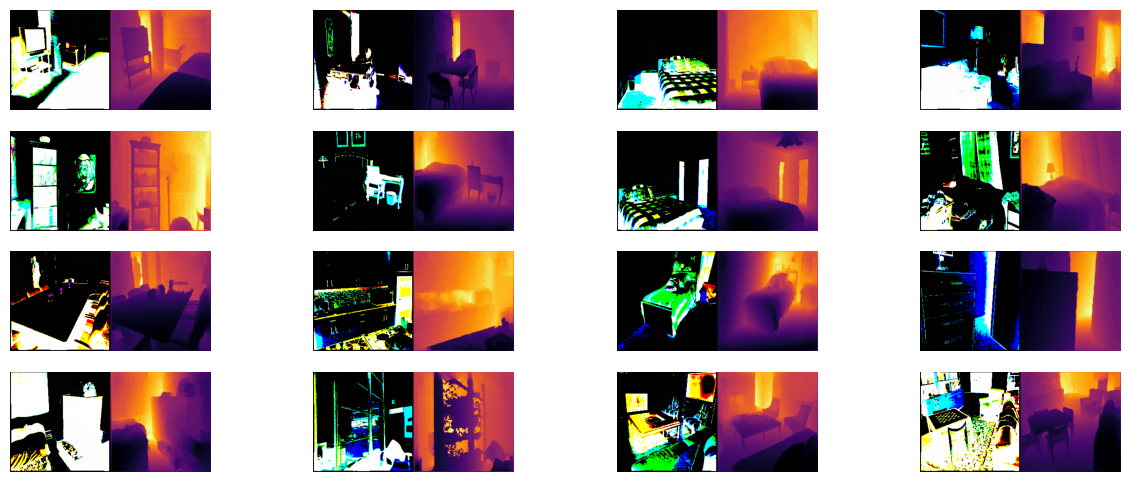

In [10]:
# -----------------------------------------
# Visualize Samples from Test Dataset
# -----------------------------------------

# Collect 16 samples from the test dataset
randoms = [test_ds[idx] for idx in range(16)]

plt.figure(figsize=(15, 6))

for i, (img, mask) in enumerate(randoms):
    
    # Create subplot grid (4x4)
    ax = plt.subplot(4, 4, i + 1)

    # Convert tensors to numpy arrays and change shape from (C,H,W) -> (H,W,C)
    img = img.permute(1, 2, 0).numpy()
    mask = mask.permute(1, 2, 0).numpy()

    # Convert depth map to colored visualization
    mask = colored_depthmap(np.squeeze(mask))

    # Concatenate RGB image and depth map side-by-side
    image_viz = np.hstack([img, mask])

    # Display the result
    plt.imshow(image_viz.astype("uint8"))
    plt.axis("off")

In [11]:
# -----------------------------------------
# Create DataLoaders
# -----------------------------------------

# Training DataLoader
# - shuffle=True to randomize batches each epoch
# - batch_size=64 for efficient GPU training
train_dl = torch.utils.data.DataLoader(
    train_ds,
    shuffle=True,
    batch_size=64
)

# Validation DataLoader
# - shuffle=False since order does not matter during evaluation
val_dl = torch.utils.data.DataLoader(
    val_ds,
    shuffle=False,
    batch_size=64
)

# Test DataLoader
# - smaller batch size to make visualization or inference easier
test_dl = torch.utils.data.DataLoader(
    test_ds,
    shuffle=True,
    batch_size=4
)

# Number of batches in each DataLoader
len(train_dl), len(val_dl), len(test_dl)


(713, 72, 127)

## **Neural Network (Unet)**

In [12]:
# -----------------------------------------
# U-Net++ Model for Depth Estimation
# -----------------------------------------

class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Initialize U-Net++ architecture from segmentation_models_pytorch
        # Encoder: ResNeXt50_32x4d pretrained backbone
        # in_channels=3 for RGB input images
        # classes=1 because we predict a single-channel depth map
        self.model = smp.UnetPlusPlus(
            encoder_name='resnext50_32x4d',
            in_channels=3,
            classes=1
        )

    # -------------------------------------
    # Freeze / Unfreeze Encoder
    # -------------------------------------
    def trainable_encoder(self, trainable=True):

        # Control whether encoder weights are updated during training
        for p in self.model.encoder.parameters():
            p.requires_grad = trainable

    # -------------------------------------
    # Forward Pass
    # -------------------------------------
    def forward(self, x):

        # Pass input through the segmentation model
        return self.model(x)

    # -------------------------------------
    # Count Trainable Parameters
    # -------------------------------------
    def _num_params(self):

        # Return the total number of trainable parameters
        return sum([p.numel() for p in self.model.parameters() if p.requires_grad])


## **Training Process**


### **Defining a new Metric**:

####  Structural Similarity Index (SSIM)

The Structural Similarity Index (SSIM) is a perceptual metric used to evaluate how similar two images are in terms of their structural content. Unlike simple pixel-wise error measures, SSIM considers how humans perceive visual information by analyzing patterns within local regions of the images. It evaluates similarity based on three main components: luminance (brightness), contrast, and structural information.

The formula for SSIM is:

$$ SSIM = \frac{(2 \mu_x \mu_y + c_1) (2 \sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1) (\sigma_x^2 + \sigma_y^2 + c_2)} $$

where μx​ and μy​ are the means of the two images, σx2​ and σy2​ are the variances of the two images, and σxy​ is the covariance of the two images. c1​ and c2​ are constants that are used to stabilize the calculation of SSIM.

Compared to Mean Squared Error (MSE), SSIM is generally more robust to noise and minor variations in the images because it focuses on structural similarity rather than raw pixel differences. However, this added perceptual awareness comes at the cost of higher computational complexity.

In many image quality assessment tasks, SSIM is preferred because it aligns more closely with human visual perception. Nevertheless, MSE remains a useful metric in scenarios where computational efficiency and simplicity are more important.

In [13]:
# -----------------------------------------
# Utility: Reverse Image Normalization
# -----------------------------------------

class UnNormalize(Normalize):

    def __init__(self, *args, **kwargs):
        # Original ImageNet normalization values used during preprocessing
        mean = (0.485, 0.456, 0.406)
        std = (0.229, 0.224, 0.225)

        # Compute inverse normalization parameters
        # This allows us to recover the original image for visualization
        new_mean = [-m / s for m, s in zip(mean, std)]
        new_std = [1 / s for s in std]

        # Initialize Normalize with inverted parameters
        super().__init__(new_mean, new_std, *args, **kwargs)


# -----------------------------------------
# Visualization: Image / Target / Prediction
# -----------------------------------------

@torch.no_grad()  # Disable gradient tracking for visualization
def plot_vals(imgs, preds, targets, n=4, figsize=(6, 2), title=''):

    # Create figure for visualization
    plt.figure(figsize=figsize, dpi=150)

    # Grid size depends on number of samples
    r = 2 if n == 4 else 8
    c = 2

    # Randomly select n samples from the batch
    for i, idx in enumerate(np.random.randint(0, imgs.size(0), (n,))):

        ax = plt.subplot(r, c, i + 1)

        # Extract image, predicted depth, and ground truth depth
        img, pred, gt = imgs[idx], preds[idx], targets[idx]

        # Reverse normalization and rescale to [0,255]
        img = UnNormalize()(img) * 255.

        # Convert tensors from (C,H,W) -> (H,W,C)
        img = img.permute(1, 2, 0).numpy()
        pred = pred.permute(1, 2, 0).numpy()
        gt = gt.permute(1, 2, 0).numpy()

        # Convert depth maps to colored representations
        pred = colored_depthmap(np.squeeze(pred))
        gt = colored_depthmap(np.squeeze(gt))

        # Merge image, ground truth depth, and predicted depth
        image_viz = np.hstack([img, pred, gt])

        # Display the result
        plt.imshow(image_viz.astype("uint8"))
        plt.axis("off")

    # Add figure title
    title = f'{title}\nimage/target/prediction' if len(title) != 0 else 'image/target/prediction'
    plt.suptitle(title)

    plt.show()


In [14]:
# -----------------------------------------
# Training Configuration
# -----------------------------------------

epochs = 5           # Total number of training epochs
freeze_epochs = 2    # Number of epochs to train decoder only (encoder frozen)

lr = 1e-3            # Maximum learning rate used in OneCycle scheduler

device = 'cuda'      # Use GPU for training


# -----------------------------------------
# Evaluation Metrics
# -----------------------------------------

# Define metrics used for evaluation
metrics = MetricCollection([
    SSIM(data_range=(0, 1)),   # Structural Similarity Index
    MSE()                      # Mean Squared Error
]).to(device)

# Separate metric trackers for train and validation
train_metrics = metrics.clone()
val_metrics = metrics.clone()


# -----------------------------------------
# Training Logs
# -----------------------------------------

# DataFrame to store training/validation metrics for each epoch
logs = pd.DataFrame()
logs[['loss_train','loss_val','ssim_train','ssim_val','mse_train','mse_val']] = None


# -----------------------------------------
# Model Initialization
# -----------------------------------------

# Create model and move it to GPU
model = UNet().to(device)

# Initially freeze encoder (train decoder only)
model.trainable_encoder(trainable=False)


# -----------------------------------------
# Loss, Optimizer, Scheduler
# -----------------------------------------

# Loss function for depth regression
loss_fn = nn.MSELoss()

# AdamW optimizer with weight decay
# Initial LR is smaller because OneCycle will increase it
optim = torch.optim.AdamW(
    model.parameters(),
    lr=lr / 25.,
    weight_decay=0.02
)

# OneCycle learning rate scheduler
sched = torch.optim.lr_scheduler.OneCycleLR(
    optim,
    max_lr=lr,
    epochs=epochs,
    steps_per_epoch=len(train_dl)
)


# -----------------------------------------
# Mixed Precision Training
# -----------------------------------------

# GradScaler helps stabilize mixed precision training
scaler = GradScaler()


Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth
100%|██████████| 95.8M/95.8M [00:01<00:00, 53.1MB/s]


training loop

training decoder only


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/72 [00:00<?, ?it/s]



  loss_train  loss_val ssim_train  ssim_val mse_train   mse_val
0   0.095343  0.009658   0.575013  0.769732  0.095367  0.009678




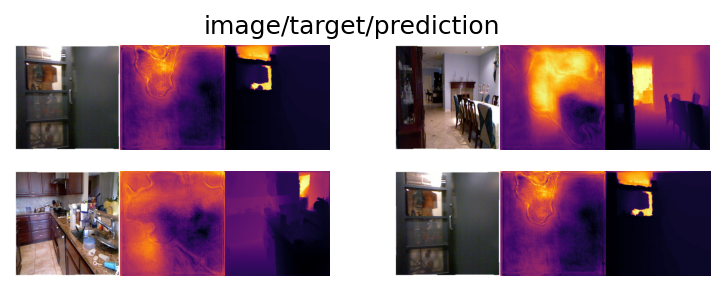

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/72 [00:00<?, ?it/s]



  loss_train  loss_val ssim_train  ssim_val mse_train   mse_val
1   0.010186  0.005739   0.841523  0.867149  0.010186  0.005754




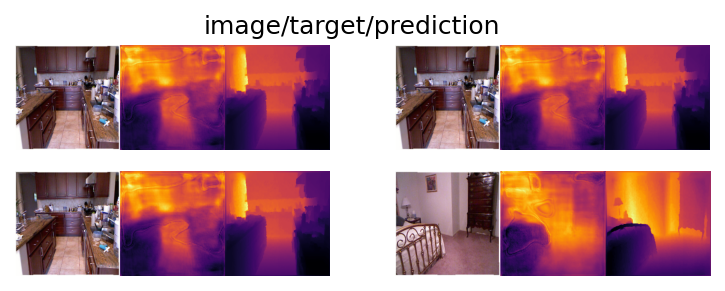

training encoder and decoder both


  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/72 [00:00<?, ?it/s]



  loss_train  loss_val ssim_train  ssim_val mse_train   mse_val
2   0.010407  0.004536   0.872432  0.888866  0.010409  0.004553




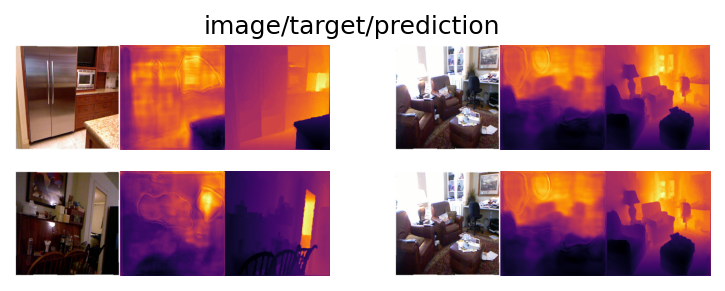

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/72 [00:00<?, ?it/s]



  loss_train  loss_val ssim_train  ssim_val mse_train   mse_val
3   0.006833  0.003201   0.897906  0.903832  0.006834  0.003213




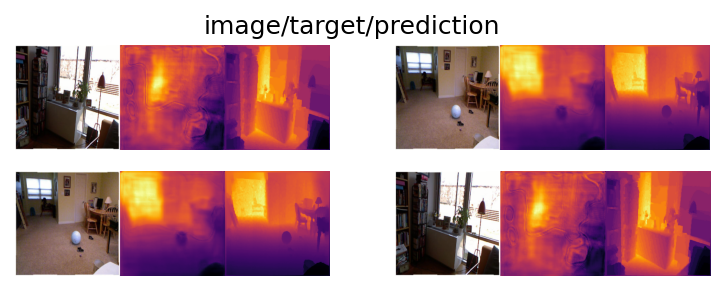

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/72 [00:00<?, ?it/s]



  loss_train loss_val ssim_train ssim_val mse_train   mse_val
4   0.005041   0.0028    0.91009  0.90911  0.005041  0.002806




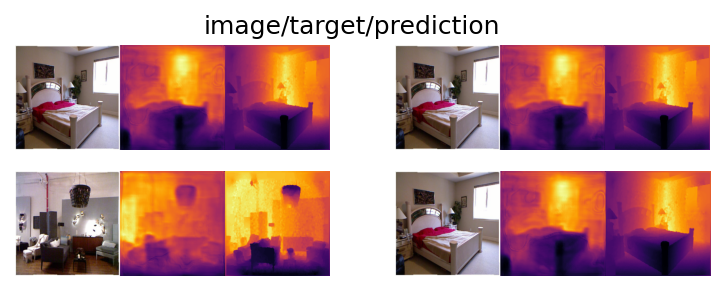

In [15]:
# -----------------------------------------
# Training Loop
# -----------------------------------------

best_ssim = -1e9     # Track best validation SSIM score
best_epoch = -1      # Track epoch where best model occurs

print('training decoder only')  # Initially only decoder is trainable


for epoch in tqdm(range(epochs)):

    # -------------------------------------
    # Training Phase
    # -------------------------------------
    model.train()

    # Unfreeze encoder after freeze_epochs
    if epoch == freeze_epochs:
        model.trainable_encoder(trainable=True)
        print('training encoder and decoder both')

    running_loss = 0.

    # Progress bar for training batches
    train_prog = tqdm(train_dl, total=len(train_dl))

    for img, mask in train_prog:

        with autocast():  # Mixed precision forward pass

            # Move data to GPU
            img, mask = img.to(device), mask.to(device)

            # Forward pass
            preds = model(img)

            # Compute loss
            loss = loss_fn(preds, mask)

            # Backpropagation with gradient scaling
            scaler.scale(loss).backward()

            # Unscale gradients before clipping
            scaler.unscale_(optim)

            # Gradient clipping to stabilize training
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0, norm_type=2)

            # Optimizer update
            scaler.step(optim)
            scaler.update()

            # Scheduler step (OneCycleLR)
            sched.step()

            # Reset gradients
            optim.zero_grad()

            running_loss += loss.item()

            # Update progress bar
            train_prog.set_description(f'loss: {loss.item():.3f}')

            # Update training metrics
            train_metrics(preds, mask)

        # Free batch tensors to reduce memory usage
        del img, mask, preds, loss

    # Compute training metrics for this epoch
    m = train_metrics.compute()
    _ssim = m['StructuralSimilarityIndexMeasure'].cpu().item()
    _mse = m['MeanSquaredError'].cpu().item()

    logs.loc[epoch, ['loss_train', 'ssim_train', 'mse_train']] = (
        running_loss / len(train_dl), _ssim, _mse
    )

    train_metrics.reset()

    # -------------------------------------
    # Validation Phase
    # -------------------------------------
    model.eval()

    with torch.no_grad():

        running_loss = 0.

        val_prog = tqdm(val_dl, total=len(val_dl))

        for img, mask in val_prog:

            with autocast():

                # Move validation batch to device
                img, mask = img.to(device), mask.to(device)

                # Forward pass
                preds = model(img)

                # Compute loss
                loss = loss_fn(preds, mask)

                running_loss += loss.item()

                val_prog.set_description(f'loss: {loss.item():.3f}')

                # Update validation metrics
                val_metrics(preds, mask)

            del img, mask, preds, loss

        # Compute validation metrics
        m = val_metrics.compute()
        _ssim = m['StructuralSimilarityIndexMeasure'].cpu().item()
        _mse = m['MeanSquaredError'].cpu().item()

        logs.loc[epoch, ['loss_val', 'ssim_val', 'mse_val']] = (
            running_loss / len(val_dl), _ssim, _mse
        )

        val_metrics.reset()

    # -------------------------------------
    # Save Best Model
    # -------------------------------------
    if _ssim > best_ssim:
        best_ssim = _ssim
        best_epoch = epoch

        # Save model weights
        sd = model.state_dict()
        torch.save(sd, 'nyu-v2-depth-resnext50_32x4d-unetplusplus.pt')

    # Print latest training logs
    print(f"\n\n{logs.tail(1)}\n\n")

    # -------------------------------------
    # Quick Visualization on Test Batch
    # -------------------------------------
    with torch.no_grad():
        with autocast():

            img, mask = next(iter(test_dl))
            img, mask = img.to(device), mask.to(device)

            preds = model(img)

            # Show image / ground truth / prediction
            plot_vals(
                img.cpu(),
                preds.cpu(),
                mask.cpu()
            )

    # Clean up GPU memory
    gc.collect()
    torch.cuda.empty_cache()

## **Analysis and Inference**


In [16]:
best_epoch

4

In [17]:
best_sd = torch.load('/kaggle/working/nyu-v2-depth-resnext50_32x4d-unetplusplus.pt')
model.load_state_dict(best_sd)

<All keys matched successfully>

  0%|          | 0/127 [00:00<?, ?it/s]

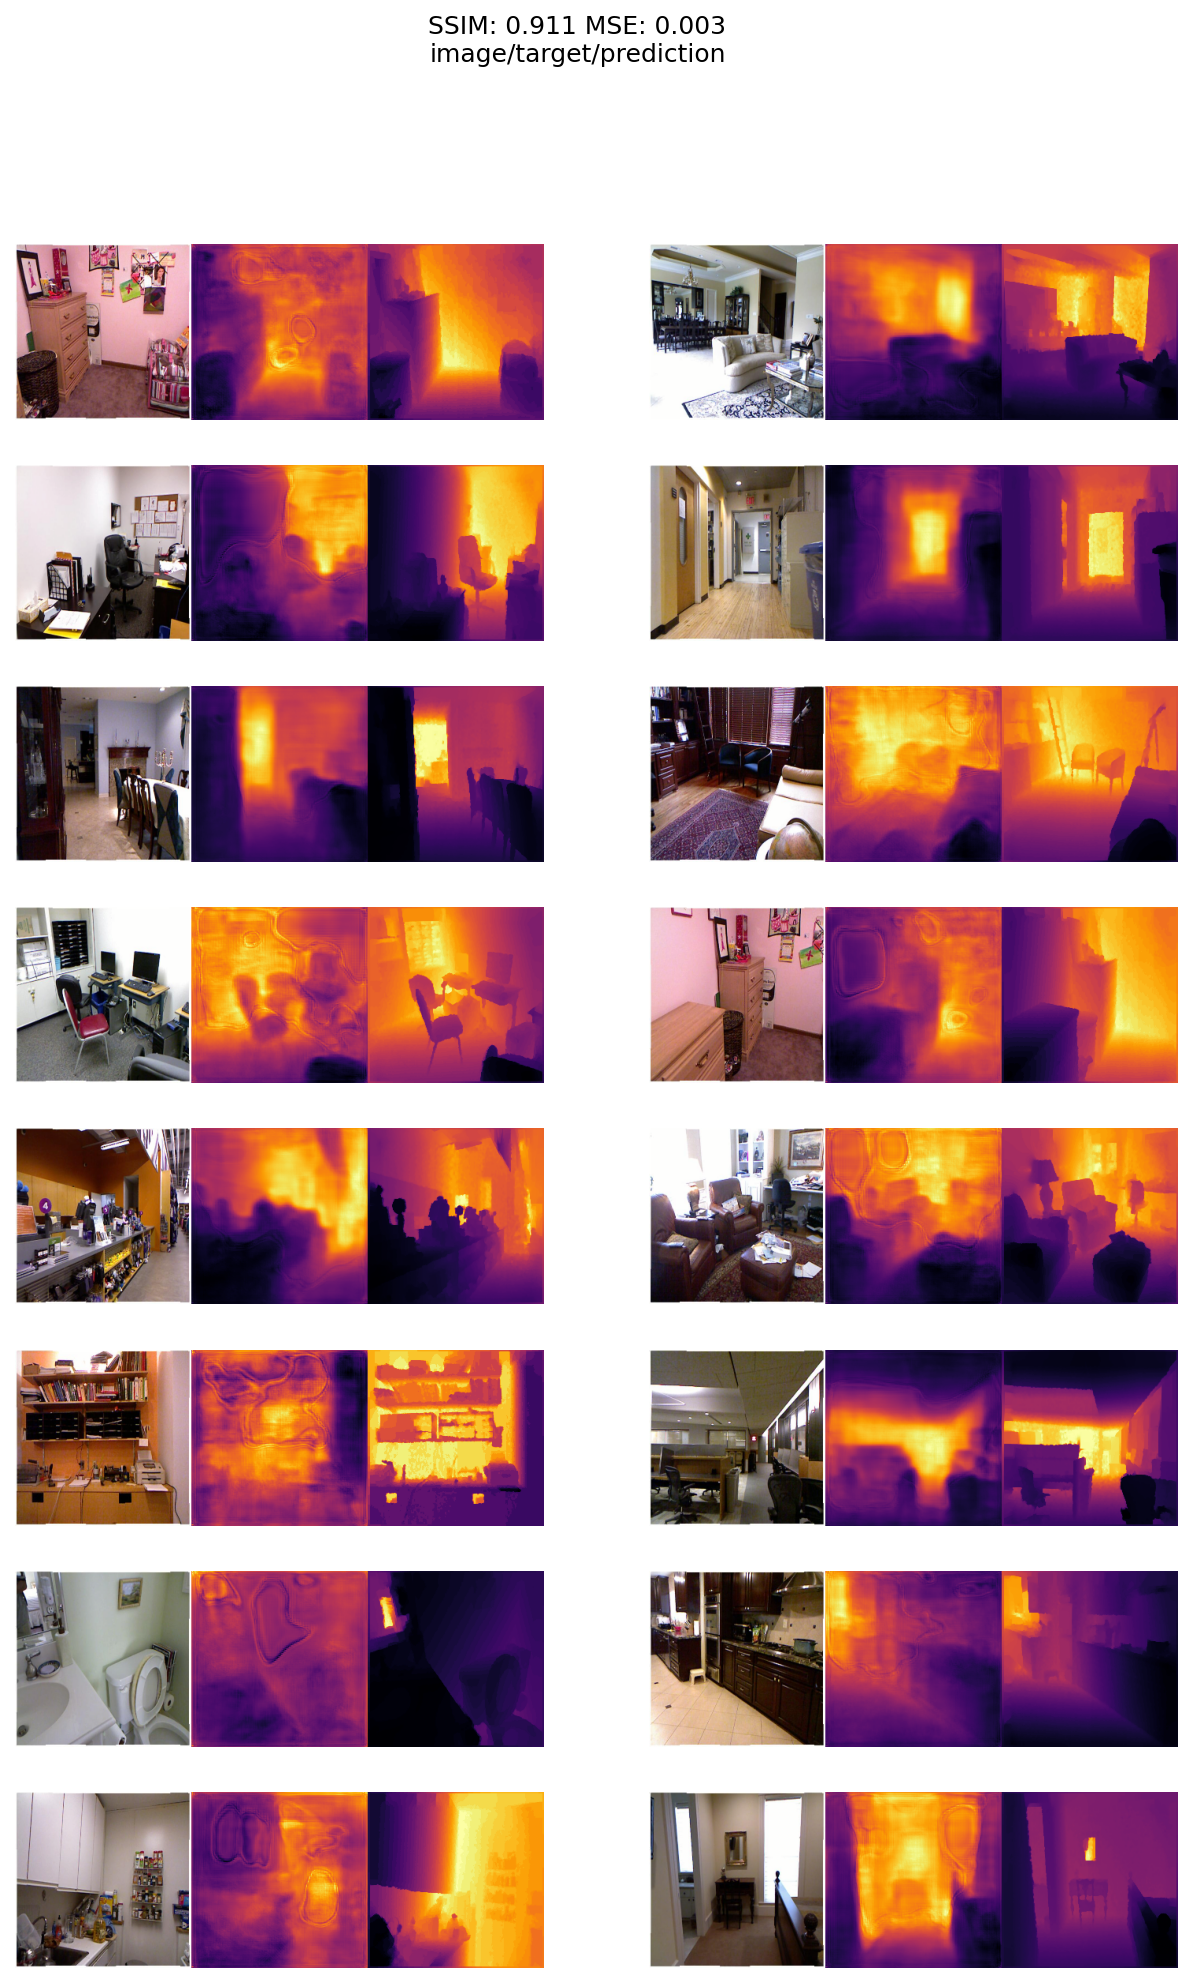

In [18]:
```python
# -----------------------------------------
# Run Inference on Test Set
# -----------------------------------------

all_imgs, all_preds, all_targets = [], [], []

# Disable gradients for evaluation
with torch.no_grad():
    with autocast():  # Mixed precision inference

        for img, mask in tqdm(test_dl, total=len(test_dl)):

            # Move batch to device
            img, mask = img.to(device), mask.to(device)

            # Forward pass
            preds = model(img)

            # Store results for later evaluation/visualization
            all_imgs.append(img)
            all_preds.append(preds)
            all_targets.append(mask)


# -----------------------------------------
# Compute Test Metrics
# -----------------------------------------

test_metrics = metrics.clone()

# Stack all batches into single tensors and evaluate
test_metrics(
    torch.vstack(all_preds),
    torch.vstack(all_targets)
)

m = test_metrics.compute()

# Create title with final evaluation scores
title = f"SSIM: {m['StructuralSimilarityIndexMeasure'].cpu().item():.3f} MSE: {m['MeanSquaredError'].cpu().item():.3f}"


# -----------------------------------------
# Visualize Predictions
# -----------------------------------------

plot_vals(
    torch.vstack(all_imgs).cpu(),
    torch.vstack(all_preds).cpu(),
    torch.vstack(all_targets).cpu(),
    n=16,
    figsize=(10, 15),
    title=title
)

## **Outcomes**

In [19]:
logs

,loss_train,loss_val,ssim_train,ssim_val,mse_train,mse_val
0,0.095343,0.009658,0.575013,0.769732,0.095367,0.009678
1,0.010186,0.005739,0.841523,0.867149,0.010186,0.005754
2,0.010407,0.004536,0.872432,0.888866,0.010409,0.004553
3,0.006833,0.003201,0.897906,0.903832,0.006834,0.003213
4,0.005041,0.0028,0.91009,0.90911,0.005041,0.002806


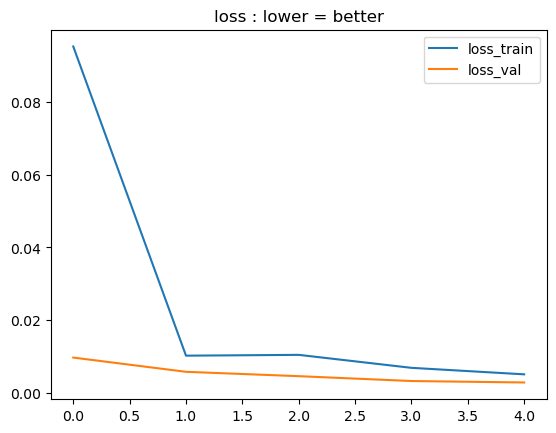

In [20]:
logs['loss_train'].plot()
logs['loss_val'].plot()
plt.title('loss : lower = better')
plt.legend()
plt.show()

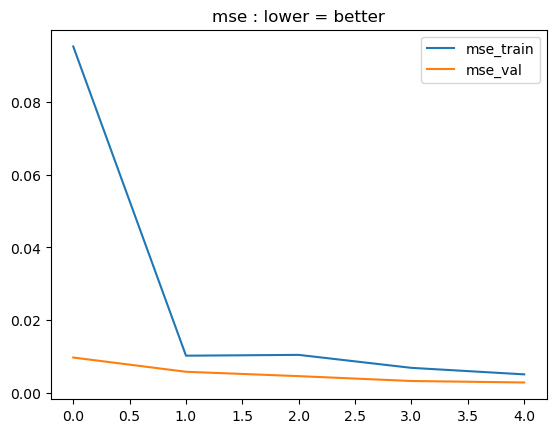

In [21]:
logs['mse_train'].plot()
logs['mse_val'].plot()
plt.title('mse : lower = better')
plt.legend()
plt.show()

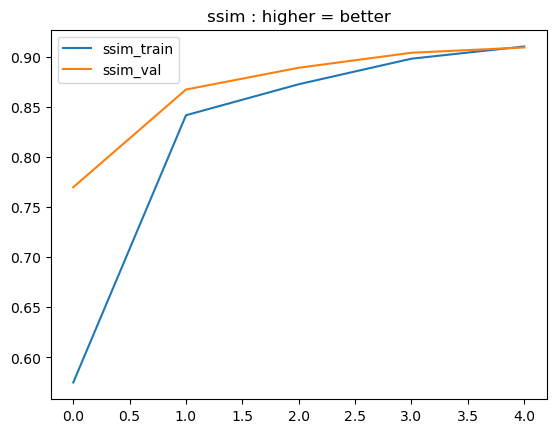

In [22]:
logs['ssim_train'].plot()
logs['ssim_val'].plot()
plt.title('ssim : higher = better')
plt.legend()
plt.show()